# Exploring the Data

### Exploring: How do age, chronic conditions, and lifestyle factors interact in stroke occurrence?

* Age (numeric)
* Residence_type (categorical)
* BMI (numeric)
* Avg_glucose_level (numeric)
* Hypertension (binary)
* Stroke (binary)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Cleaning

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

df.isna().sum()
## bmi has missing values. This will be used as a BMI-specific dataframe
df_bmi = df.dropna(subset=["bmi"])

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


The BMI variable contains missing values for a subset of patients.
Because BMI is not required for all analyses in this notebook, rows with missing BMI
were not removed from the full dataset. Instead, a BMI-specific subset of the data was 
created for analyses involving body mass index. This approach preserves the full sample 
size for different variable analyses while allowing BMI to be explored 
without imputation.

In [3]:
after = df_bmi["stroke"].value_counts(normalize=True) * 100
before = df["stroke"].value_counts(normalize=True) * 100

print(f"Before dropping BMI: {before}")
print(f"After dropping BMI: {after}")

Before dropping BMI: stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64
After dropping BMI: stroke
0    95.742514
1     4.257486
Name: proportion, dtype: float64


Stroke cases represent a relatively small proportion of the dataset (~4.9%), 
indicating that stroke is a rare outcome in the observed population. 

## Age & Stroke 

In [14]:
df["age_group"] = pd.cut(df["age"], bins=[0, 40, 60, 100],labels=["<40", "40–60", "60+"])

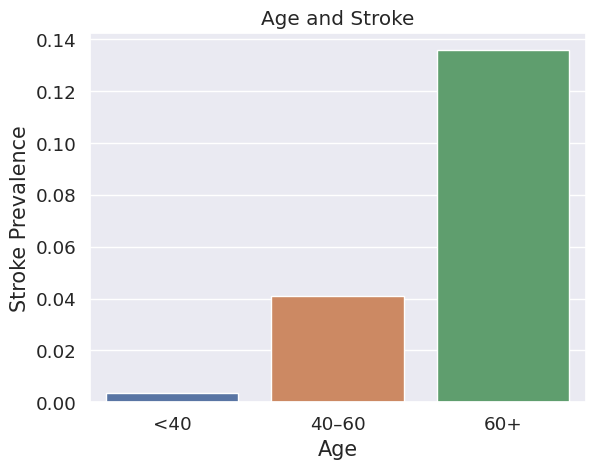

In [16]:
stroke_age = (df.groupby("age_group")["stroke"].mean().reset_index())

sns.barplot(data=stroke_age, x="age_group", y="stroke")
sns.set(font_scale=1.2)
plt.xlabel("Age", fontsize=15)
plt.ylabel("Stroke Prevalence", fontsize=15)
plt.title("Age and Stroke")
plt.show()

Observation: The age distribution for stroke patients is strongly shifted toward older ages, with stroke occurrence becoming much more common after midlife.


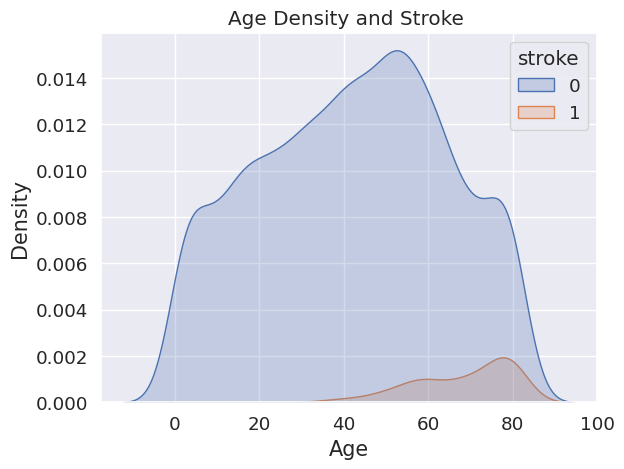

In [12]:
sns.kdeplot(data=df, x="age", hue="stroke", fill=True)

plt.xlabel("Age", fontsize=15)
plt.ylabel("Density", fontsize=15)
plt.title("Age Density and Stroke ")
plt.show()

Observation: This density plot highlights differences in age distributions between stroke and non-stroke
cases. Stroke cases are concentrated at older ages, while non-stroke cases are spread 
across the full age range. You can also see the low density for stroke cases in general.

## Residence & Stroke

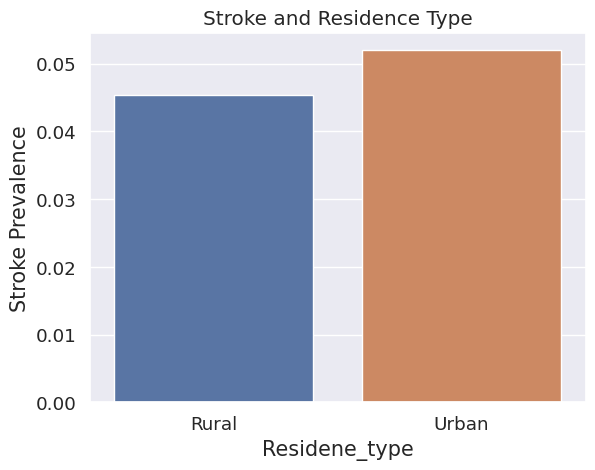

In [17]:
stroke_residence = (df.groupby("Residence_type")["stroke"].mean().reset_index())

sns.barplot(data=stroke_residence, x="Residence_type", y="stroke")
sns.set(font_scale=1.2)
plt.ylabel("Stroke Prevalence", fontsize=15)
plt.xlabel("Residene_type", fontsize=15)
plt.title("Stroke and Residence Type")
plt.show()

Observation: Stroke prevalence is slightly higher among urban residents than rural residents.
The difference between urban and rural areas is small, indicating that residence type 
alone does not strongly distinguish stroke occurrence.

## BMI and Stroke

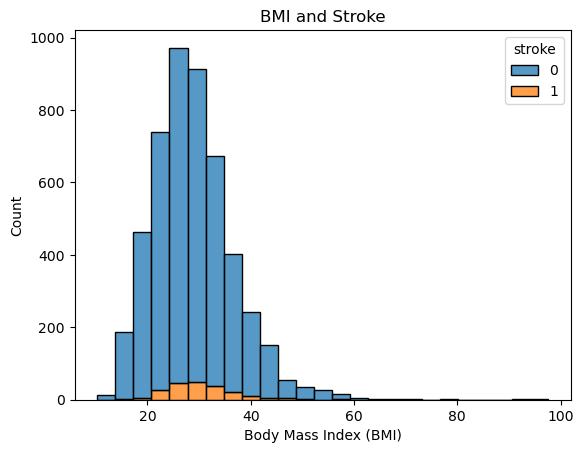

In [144]:
sns.histplot(data=df_bmi, x="bmi", hue="stroke", bins=25, multiple="stack")

plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Count")
plt.title("BMI and Stroke")
plt.show()

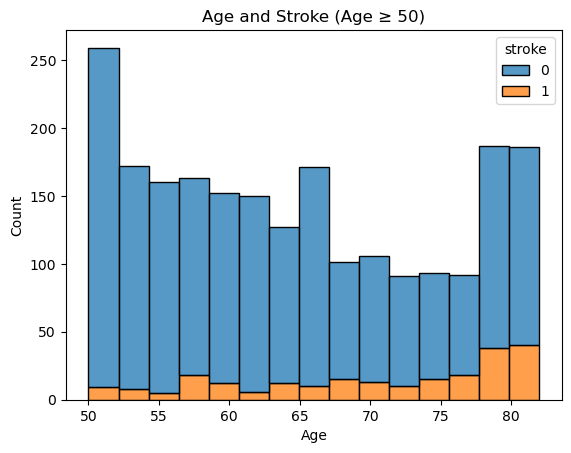

In [143]:
older_df = df[df["age"] >= 50]

sns.histplot(data=older_df, x="age", hue="stroke", bins=15, multiple="stack")

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age and Stroke (Age ≥ 50)")
plt.show()

Observation:

df_bmi = This stacked histogram shows the distribution of BMI values for individuals with and without stroke. The stroke group represents a small portion of the data and overlaps heavily with the non-stroke group, indicating that BMI alone does not clearly distinguish stroke occurrence.

older_df = This histogram focuses on individuals aged 50 and older to better visualize stroke cases, which are rare at younger ages. Stroke occurrences are concentrated at later ages, highlighting the strong relationship between increasing age and stroke prevalence.

## Glucose & Stroke

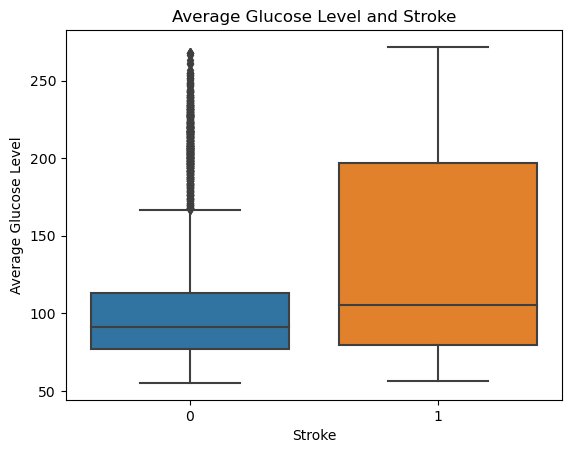

In [122]:
sns.boxplot(data=df,x="stroke", y="avg_glucose_level")

plt.xlabel("Stroke")
plt.ylabel("Average Glucose Level")
plt.title("Average Glucose Level and Stroke")
plt.show()

Observation: Higher average glucose levels are more common among individuals who experienced a stroke, 
indicating that elevated glucose may be an important supporting factor associated with
stroke occurrence.

## Age × Average Glucose Level → Stroke Prevalence

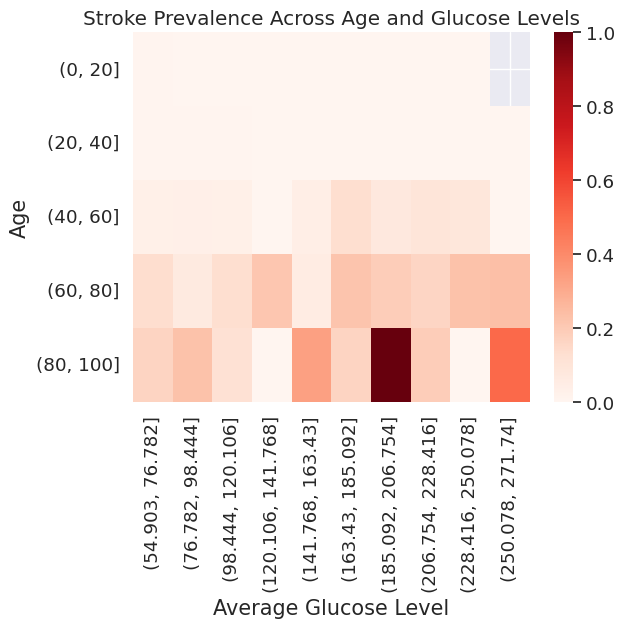

In [18]:
df["age_bin"] = pd.cut(df["age"], bins=[0, 20, 40, 60, 80, 100])
df["glucose_bin"] = pd.cut(df["avg_glucose_level"], bins=10)
data_heat = (df.groupby(["age_bin", "glucose_bin"])["stroke"].mean().unstack())

sns.heatmap(data=data_heat, cmap="Reds")
sns.set(font_scale=1.2)
plt.xlabel("Average Glucose Level", fontsize=15)
plt.ylabel("Age", fontsize=15)
plt.title("Stroke Prevalence Across Age and Glucose Levels")
plt.show()

Observation: 

This plot looks at how age and lifestyle-related factors interact in stroke occurrence.

This heat map shows how stroke prevalence varies across combinations of age and 
average glucose level. Darker regions indicate a higher proportion of individuals who 
experienced a stroke. We can see one extremely darker region, relative to the other regions, around 185-206 average glucose level and aged 80-100.


## Age Group vs. Hypertension vs. Stroke Prevalence

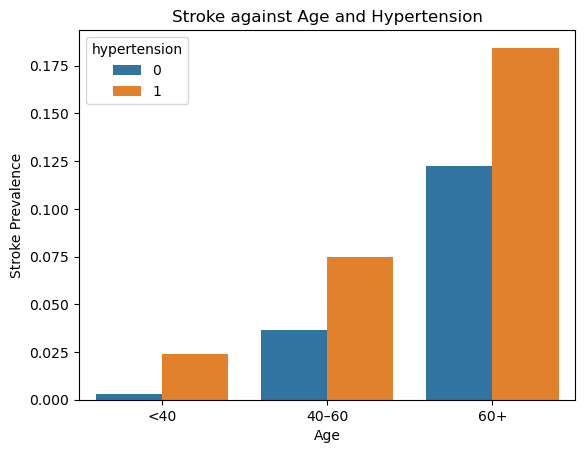

In [125]:
stroke_age_htn = (df.groupby(["age_group", "hypertension"])["stroke"].mean().reset_index())

sns.barplot(data=stroke_age_htn, x="age_group", y="stroke", hue="hypertension")
plt.xlabel("Age")
plt.ylabel("Stroke Prevalence")
plt.title("Stroke against Age and Hypertension")
plt.show()

Observation: Stroke prevalence increases across age groups for all individuals, but is consistently higher among those with hypertension. The difference between hypertensive and non-hypertensive individuals becomes highlighted in the 60+ age group.

## Summary 

#### These observations guided the selection of variables and plots for the final infographic.

Age shows the clearest visual separation between stroke and non-stroke groups.

Stroke prevalence differs modestly between urban and rural populations.

Average glucose levels are generally higher among patients who experienced a stroke.
